In [7]:
import numpy as np
from astropy.io import fits
import matplotlib.pyplot as plt

In [2]:
def show(fitsfile):
    # Load the FITS file
    hdul1 = fits.open(fitsfile)
    print(hdul[1])

In [3]:
def getarray(fitsfile):
    # Load the FITS file
    hdul1 = fits.open(fitsfile)
    x = []
    for i in range(len(hdul1[2].data)):
        x.append(hdul1[2].data[i][3])
    for i in range(len(hdul1[3].data)):
        x.append(hdul1[3].data[i][3])
    y = np.array(x)
    
    return(y)

In [4]:
xipm_des = getarray("../data/dv/sim_2pt-NLA-cosmoDESY3.fits")
xipm_cosmogrid = getarray("../data/dv/sim_2pt-NLA-cosmoCosmoG.fits")

In [5]:
print(len(xipm_des))
print(len(xipm_cosmogrid))

400
400


In [6]:
ratio = xipm_des/xipm_cosmogrid

In [7]:
print(ratio)

[0.37085238 0.37560264 0.3801489  0.38415392 0.38723776 0.38903523
 0.3892803  0.38790081 0.38508162 0.38126513 0.37707637 0.37320232
 0.37025623 0.36867898 0.36870581 0.37040631 0.37376581 0.37868621
 0.38496574 0.39229881 0.49255696 0.49569009 0.49827129 0.50000542
 0.50063039 0.49998666 0.49808526 0.49514516 0.49156514 0.48783574
 0.48443302 0.4817391  0.48000246 0.47933732 0.47975216 0.48119097
 0.48357335 0.48679751 0.49064392 0.49464556 0.47800478 0.48101381
 0.48336589 0.48474426 0.48489234 0.48369461 0.48124098 0.47784521
 0.47398571 0.47019145 0.46692996 0.46454255 0.4632289  0.46306912
 0.46406174 0.46615233 0.46928328 0.47332671 0.47822909 0.48338637
 0.47429456 0.47739392 0.47990845 0.48147044 0.48177209 0.48064987
 0.4781521  0.47455838 0.47032441 0.46597389 0.46199231 0.45876283
 0.45654502 0.45548982 0.45566838 0.45708752 0.45975043 0.4636719
 0.46881502 0.4735188  0.78068471 0.77861197 0.77606536 0.77317092
 0.77012903 0.76716621 0.76446462 0.76209711 0.75999917 0.75799

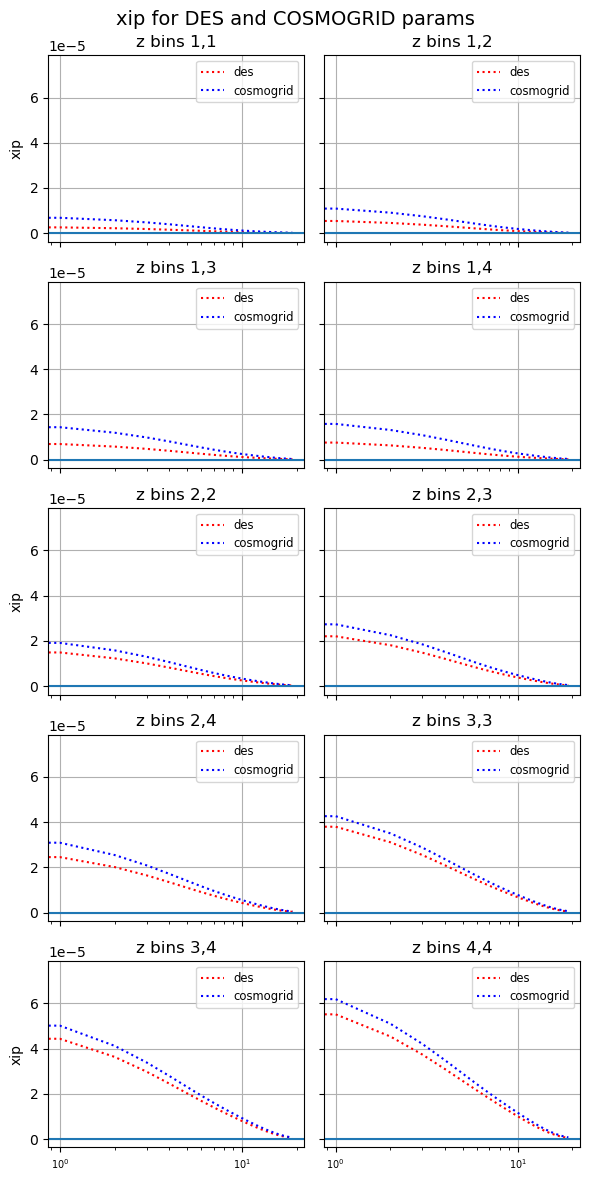

In [32]:
xipm_des_sec = np.split(xipm_des, 20)[:200]
xipm_cmg_sec = np.split(xipm_cosmogrid, 20)[:200]

indx = [[1,1],[1,2],[1,3],[1,4],[2,2],[2,3],[2,4],[3,3],[3,4],[4,4]]

fig, axs = plt.subplots(5, 2, figsize=(6, 12), sharey=True, sharex=True)

# Flatten the axes array for easy iteration
axs = axs.flatten()

# Iterate over each subplot and plot the data
for i, ax in enumerate(axs):
    x_values = np.arange(20)
    ax.plot(x_values, xipm_des_sec[i], color='r', ls=':',label='des')
    ax.plot(x_values, xipm_cmg_sec[i], color='b', ls=':',label='cosmogrid')
    ax.axhline(y=0)
    ax.set_title(f'z bins {indx[i][0]},{indx[i][1]}')
    if i >= 16:
        ax.set_xlabel(r"Index")
    
    ax.tick_params(axis='x', which='both', labelsize=7) 
        
    # Set y labels only for the leftmost column of subplots
    if i % 4 == 0:
        ax.set_ylabel(r"xip")
        
    #ax.set_yscale("log")
    ax.set_xscale("log")
    ax.grid()
    ax.legend(fontsize='small')

fig.suptitle(r"xip for DES and COSMOGRID params", fontsize=14)
    
# Adjust layout to prevent overlap of subplots
plt.tight_layout()

# Show the plot
plt.show()

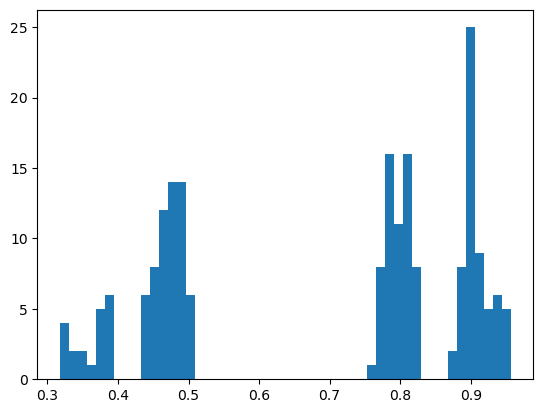

In [8]:
plt.hist(ratio[200:400],50)
plt.show()

In [9]:
from scipy import stats

def mean_wo(data, z_threshold=1.5):
    # Compute the Z-scores of the data
    z_scores = stats.zscore(data)
    # Filter out the data points with a Z-score greater than the threshold
    filtered_data = data[np.abs(z_scores) < z_threshold]
    # Compute the mean of the filtered data
    mean = np.mean(filtered_data)
    return mean

In [10]:
new_matrix = np.ndarray(shape=(10,20))
for i in range(10):
    #new_matrix[i] = np.concatenate((ratio[i*20:(i+1)*20], ratio[200+i*20:200+(i+1)*20]))
    new_matrix[i] = ratio[i*20:(i+1)*20]

In [11]:
print(np.mean(ratio))
print(np.median(ratio))
print(mean_wo(ratio))

0.6765224174603436
0.767921817099851
0.7001225531981949


In [12]:
print(np.sqrt(mean_wo(new_matrix[0])))

0.6154289246213622


In [13]:
print(np.sqrt(mean_wo(new_matrix[4])))

0.8701181693449714


In [14]:
print(np.sqrt(mean_wo(new_matrix[7])))

0.927485483803646


In [15]:
print(np.sqrt(mean_wo(new_matrix[9])))

0.9245707197726286


In [19]:
#see if doing sqrt of auto recovers the rest:

#1,2
print(np.sqrt(mean_wo(new_matrix[0]))*np.sqrt(mean_wo(new_matrix[4])))
print((mean_wo(new_matrix[0])+mean_wo(new_matrix[4]))/2)
print(mean_wo(new_matrix[1]))

0.5354958892534841
0.5679291949424254
0.4900943746326627


In [20]:
#see if doing sqrt of auto recovers the rest:

#1,3
print(np.sqrt(mean_wo(new_matrix[0]))*np.sqrt(mean_wo(new_matrix[7])))
print((mean_wo(new_matrix[0])+mean_wo(new_matrix[7]))/2)
print(mean_wo(new_matrix[2]))

0.5708013938992017
0.6194910419635449
0.47455945470678856


In [18]:
#see if doing sqrt of auto recovers the rest:

#1,4
print(np.sqrt(mean_wo(new_matrix[0]))*np.sqrt(mean_wo(new_matrix[9])))
print(mean_wo(new_matrix[3]))

0.5690075638060677
0.4687900072439934


In [81]:
#see if doing sqrt of auto recovers the rest:

#2,3
print(np.sqrt(mean_wo(new_matrix[4]))*np.sqrt(mean_wo(new_matrix[7])))
print(mean_wo(new_matrix[5]))

0.7985530493263937
0.7752845914876723


In [82]:
#see if doing sqrt of auto recovers the rest:

#2,4
print(np.sqrt(mean_wo(new_matrix[4]))*np.sqrt(mean_wo(new_matrix[9])))
print(mean_wo(new_matrix[6]))

0.7951299444619495
0.7622043315919939


In [83]:
#see if doing sqrt of auto recovers the rest:

#3,4
print(np.sqrt(mean_wo(new_matrix[7]))*np.sqrt(mean_wo(new_matrix[9])))
print(mean_wo(new_matrix[8]))

0.8441990003163631
0.8396303949179897


In [5]:
from astropy.io import fits
look = fits.open('/Users/gchgomes/3pcf_integrator/data/dv/meas_2pt-ave-cosmogrid.fits')
look2 = fits.open('/Users/gchgomes/3pcf_integrator/data/dv/meas_map3-ave-cosmogrid.fits')
look3 = fits.open('/Users/gchgomes/3pcf_integrator/data/covariance/cov_xip_xim_map3.fits')

In [21]:
look2.info()
print(np.shape(look2[2].data))

Filename: /Users/gchgomes/3pcf_integrator/data/dv/meas_map3-ave-cosmogrid.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU       4   ()      
  1  map3          1 BinTableHDU     29   80R x 7C   ['K', 'K', 'K', 'D', 'D', 'D', 'D']   
  2  COVMAT        1 ImageHDU        12   (80, 80)   float64   
(80, 80)


In [16]:
import numpy as np
# Open the FITS file
file_path = '/Users/gchgomes/3pcf_integrator/data/dv/meas_2pt-ave-cosmogrid.fits'
with fits.open(file_path, mode='update') as hdul:
    # Print the info of the FITS file to understand its structure
    print(hdul[3].data)

    new_dv = np.load('/Users/gchgomes/3pcf_integrator/data/xip_xim_map3_dv_and_cov/24Jul_xip_xim_map3_DV.npy')
    for i in range(200):
        hdul[2].data[i][3] = new_dv[i]
        hdul[3].data[i][3] = new_dv[i+200]
    
    print(hdul[3].data)

    # Save the changes to a new file
    new_file_path = '/Users/gchgomes/3pcf_integrator/data/dv/meas_2pt-ave-cosmogrid_weighted.fits'
    hdul.writeto(new_file_path, overwrite=True)

[(1, 1,  0, -1.33898379e-06,   2.5       ,   3.14731353,   2.83602296)
 (1, 1,  1, -9.03173216e-07,   3.14731353,   3.96223298,   3.57034138)
 (1, 1,  2,  6.33880030e-07,   3.96223298,   4.98815579,   4.49479349)
 (1, 1,  3,  1.81763040e-06,   4.98815579,   6.27971608,   5.65860974)
 (1, 1,  4,  7.22356879e-07,   6.27971608,   7.90569415,   7.1237676 )
 (1, 1,  5,  7.86093705e-07,   7.90569415,   9.95267926,   8.96829206)
 (1, 1,  6,  1.10580060e-06,   9.95267926,  12.52968084,  11.29041078)
 (1, 1,  7,  1.33592994e-06,  12.52968084,  15.77393361,  14.21378504)
 (1, 1,  8,  6.87440035e-07,  15.77393361,  19.85820587,  17.89409518)
 (1, 1,  9,  8.62294478e-07,  19.85820587,  25.        ,  22.52733114)
 (1, 1, 10,  5.70169514e-07,  25.        ,  31.47313529,  28.36022963)
 (1, 1, 11,  4.60529605e-07,  31.47313529,  39.62232981,  35.70341377)
 (1, 1, 12,  4.40872381e-07,  39.62232981,  49.88155787,  44.94793488)
 (1, 1, 13,  5.07736473e-07,  49.88155787,  62.79716079,  56.58609743)
 (1, 1

In [40]:
file_path = '/Users/gchgomes/3pcf_integrator/data/dv/meas_map3-ave-cosmogrid.fits'
with fits.open(file_path, mode='update') as hdul:
    # Print the info of the FITS file to understand its structure
    print(hdul[2].data)

    new_dv = np.load('/Users/gchgomes/3pcf_integrator/data/xip_xim_map3_dv_and_cov/24Jul_xip_xim_map3_DV.npy')
    covv = np.load('/Users/gchgomes/3pcf_integrator/data/map3_dv_and_cov/24Jul_map3_COV.npy')
    for i in range(80):
        hdul[1].data[i][6] = new_dv[400+i]
        hdul[2].data[i] = covv[i]
    
    hdul[2].header['NSIM'] = 500
    print(hdul[2].header)

    # Save the changes to a new file
    new_file_path = '/Users/gchgomes/3pcf_integrator/data/dv/meas_map3-ave-cosmogrid_weighted.fits'
    hdul.writeto(new_file_path, overwrite=True)

[[ 9.00805435e-17  3.71361443e-18  1.76978795e-19 ... -7.68826410e-19
  -7.38833550e-20 -1.92508345e-21]
 [ 3.71361443e-18  4.18270838e-19  2.53137321e-20 ... -2.49910571e-20
   3.29195856e-21  3.22420531e-22]
 [ 1.76978795e-19  2.53137321e-20  5.31688166e-21 ... -3.01952547e-21
  -6.01301919e-23  4.36165851e-23]
 ...
 [-7.68826410e-19 -2.49910571e-20 -3.01952547e-21 ...  5.36151748e-18
   3.03393869e-19  2.42035483e-20]
 [-7.38833550e-20  3.29195856e-21 -6.01301919e-23 ...  3.03393869e-19
   5.34636775e-20  6.07488940e-21]
 [-1.92508345e-21  3.22420531e-22  4.36165851e-23 ...  2.42035483e-20
   6.07488940e-21  1.77123933e-21]]
XTENSION= 'IMAGE   '           / Image extension                                BITPIX  =                  -64 / array data type                                NAXIS   =                    2 / number of array dimensions                     NAXIS1  =                   80                                                  NAXIS2  =                   80              

In [4]:
look2.info()

Filename: /Users/gchgomes/3pcf_integrator/data/dv/meas_map3-ave-cosmogrid.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU       4   ()      
  1  map3          1 BinTableHDU     29   80R x 7C   [K, K, K, D, D, D, D]   
  2  COVMAT        1 ImageHDU        12   (80, 80)   float64   


In [31]:
file_path = '/Users/gchgomes/3pcf_integrator/data/covariance/cov_xip_xim_map3.fits'
with fits.open(file_path, mode='update') as hdul:
    # Print the info of the FITS file to understand its structure
    print(hdul[1].header)

    covv = np.load('/Users/gchgomes/3pcf_integrator/data/xip_xim_map3_dv_and_cov/24Jul_xip_xim_map3_COV.npy')
    for i in range(480):
        hdul[1].data[i] = covv[i]
    
    hdul[1].header['NSIM'] = 500
    print(hdul[1].header)

    # Save the changes to a new file
    new_file_path = '/Users/gchgomes/3pcf_integrator/data/covariance/cov_xip_xim_map3_weighted.fits'
    hdul.writeto(new_file_path, overwrite=True)

XTENSION= 'IMAGE   '           / Image extension                                BITPIX  =                  -64 / array data type                                NAXIS   =                    2 / number of array dimensions                     NAXIS1  =                  480                                                  NAXIS2  =                  480                                                  PCOUNT  =                    0 / number of parameters                           GCOUNT  =                    1 / number of groups                               EXTNAME = 'COVMAT  '                                                            NSIM    =                  500                                                  3PT_DATA=                    T                                                  STRT_0  =                    0                                                  NAME_0  = 'xip     '                                                            STRT_1  =                  200          

In [39]:
look2.info()
print(look2[2].header)

Filename: /Users/gchgomes/3pcf_integrator/data/dv/meas_map3-ave-cosmogrid.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU       4   ()      
  1  map3          1 BinTableHDU     29   80R x 7C   ['K', 'K', 'K', 'D', 'D', 'D', 'D']   
  2  COVMAT        1 ImageHDU        12   (80, 80)   float64   
XTENSION= 'IMAGE   '           / Image extension                                BITPIX  =                  -64 / array data type                                NAXIS   =                    2 / number of array dimensions                     NAXIS1  =                   80                                                  NAXIS2  =                   80                                                  PCOUNT  =                    0 / number of parameters                           GCOUNT  =                    1 / number of groups                               EXTNAME = 'COVMAT  '                                                            NSIM    =   

In [2]:
from astropy.io import fits
blind_file = '/Users/gchgomes/3pcf_integrator/data/dv/blind-metacal-2pt-DESY3.fits'
blnd = fits.open(blind_file)
blnd.info()

Filename: /Users/gchgomes/3pcf_integrator/data/dv/blind-metacal-2pt-DESY3.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU       4   ()      
  1  COVMAT        1 ImageHDU        17   (900, 900)   float64   
  2  xip           1 BinTableHDU     35   200R x 7C   [K, K, K, D, D, D, D]   
  3  xim           1 BinTableHDU     35   200R x 7C   [K, K, K, D, D, D, D]   
  4  nz_source     1 BinTableHDU     24   301R x 7C   [D, D, D, D, D, D, D]   


In [4]:
simcov = '/Users/gchgomes/3pcf_integrator/data/dv/blind-metacal-2pt-DESY3-SimCov.fits'
smcv = fits.open(simcov)
smcv.info()

Filename: /Users/gchgomes/3pcf_integrator/data/dv/blind-metacal-2pt-DESY3-SimCov.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU       4   ()      
  1  COVMAT        1 ImageHDU        17   (400, 400)   float64   
  2  xip           1 BinTableHDU     35   200R x 7C   [K, K, K, D, D, D, D]   
  3  xim           1 BinTableHDU     35   200R x 7C   [K, K, K, D, D, D, D]   
  4  nz_source     1 BinTableHDU     24   301R x 7C   [D, D, D, D, D, D, D]   


In [7]:
import numpy as np
with fits.open(simcov, mode='update') as hdul:
    # Print the info of the FITS file to understand its structure
    print(hdul[1].header)

    covv = np.load('/Users/gchgomes/3pcf_integrator/data/2pcf_dv_and_cov/24Jul_2PCF_COV.npy')
    for i in range(400):
        hdul[1].data[i] = covv[i]

    # Save the changes to a new file
    new_file_path = '/Users/gchgomes/3pcf_integrator/data/dv/blind-metacal-2pt-DESY3-SimCov-weighted.fits'
    hdul.writeto(new_file_path, overwrite=True)

XTENSION= 'IMAGE   '           / Image extension                                BITPIX  =                  -64 / array data type                                NAXIS   =                    2 / number of array dimensions                     NAXIS1  =                  400                                                  NAXIS2  =                  400                                                  PCOUNT  =                    0 / number of parameters                           GCOUNT  =                    1 / number of groups                               COVDATA =                    T                                                  EXTNAME = 'COVMAT  '                                                            STRT_0  =                    0                                                  NAME_0  = 'xip     '                                                            STRT_1  =                  200                                                  NAME_1  = 'xim     '                    

In [8]:
from astropy.io import fits
blind_file2 = '/Users/gchgomes/3pcf_integrator/data/dv/blind-metacal-2pt-DESY3-SimCov-weighted.fits'
blnd2 = fits.open(blind_file2)
blnd2.info()

Filename: /Users/gchgomes/3pcf_integrator/data/dv/blind-metacal-2pt-DESY3-SimCov-weighted.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU       4   ()      
  1  COVMAT        1 ImageHDU        17   (400, 400)   float64   
  2  xip           1 BinTableHDU     35   200R x 7C   [K, K, K, D, D, D, D]   
  3  xim           1 BinTableHDU     35   200R x 7C   [K, K, K, D, D, D, D]   
  4  nz_source     1 BinTableHDU     24   301R x 7C   [D, D, D, D, D, D, D]   


In [11]:
from astropy.io import fits
blind_map3 = '/Users/gchgomes/3pcf_integrator/data/dv/real_map3_desy3_blind.fits'
blmap3 = fits.open(blind_map3)
blmap3.info()
blmap3[2].header

Filename: /Users/gchgomes/3pcf_integrator/data/dv/real_map3_desy3_blind.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU       4   ()      
  1  map3          1 BinTableHDU     29   80R x 7C   [K, K, K, D, D, D, D]   
  2  COVMAT        1 ImageHDU        12   (80, 80)   float64   


XTENSION= 'IMAGE   '           / Image extension                                
BITPIX  =                  -64 / array data type                                
NAXIS   =                    2 / number of array dimensions                     
NAXIS1  =                   80                                                  
NAXIS2  =                   80                                                  
PCOUNT  =                    0 / number of parameters                           
GCOUNT  =                    1 / number of groups                               
EXTNAME = 'COVMAT  '                                                            
NSIM    =                  400                                                  
3PT_DATA=                    T                                                  
STRT_0  =                    0                                                  
NAME_0  = 'map3    '                                                            

In [13]:
with fits.open(blind_map3, mode='update') as hdul:
    # Print the info of the FITS file to understand its structure
    print(hdul[2].header)

    covv = np.load('/Users/gchgomes/3pcf_integrator/data/map3_dv_and_cov/24Jul_MAP3_COV.npy')
    for i in range(80):
        hdul[2].data[i] = covv[i]
    
    hdul[2].header['NSIM'] = 500
    print(hdul[2].header)

    # Save the changes to a new file
    new_file_path = '/Users/gchgomes/3pcf_integrator/data/dv/real_map3_desy3_blind_weightedcov.fits'
    hdul.writeto(new_file_path, overwrite=True)

XTENSION= 'IMAGE   '           / Image extension                                BITPIX  =                  -64 / array data type                                NAXIS   =                    2 / number of array dimensions                     NAXIS1  =                   80                                                  NAXIS2  =                   80                                                  PCOUNT  =                    0 / number of parameters                           GCOUNT  =                    1 / number of groups                               EXTNAME = 'COVMAT  '                                                            NSIM    =                  400                                                  3PT_DATA=                    T                                                  STRT_0  =                    0                                                  NAME_0  = 'map3    '                                                            END                                     

In [3]:
blnd[1].header

XTENSION= 'IMAGE   '           / Image extension                                
BITPIX  =                  -64 / array data type                                
NAXIS   =                    2 / number of array dimensions                     
NAXIS1  =                  900                                                  
NAXIS2  =                  900                                                  
PCOUNT  =                    0 / number of parameters                           
GCOUNT  =                    1 / number of groups                               
COVDATA =                    T                                                  
EXTNAME = 'COVMAT  '                                                            
STRT_0  =                    0                                                  
NAME_0  = 'xip     '                                                            
STRT_1  =                  200                                                  
NAME_1  = 'xim     '        

In [2]:
``import numpy as np
from astropy.io import fits
# Open the FITS file
file_path = '/Users/gchgomes/3pcf_integrator/data/dv/meas_2pt-ave-cosmogrid_copy.fits'
with fits.open(file_path) as hdul:
    # Print the info of the FITS file to understand its structure
    print(hdul[3].data)

    new_dv = np.load('/Users/gchgomes/3pcf_integrator/data/dv/2pcf_cosmogrid_run0000_cut00_real00_all.npy')
    for i in range(200):
        hdul[2].data[i][3] = new_dv[i]
        hdul[3].data[i][3] = new_dv[i+200]
    
    print(hdul[3].data)

    # Save the changes to a new file
    new_file_path = '/Users/gchgomes/3pcf_integrator/data/dv/meas_2pt-sim1-cosmogrid.fits'
    hdul.writeto(new_file_path)

[(1, 1,  0, -1.70420897e-07,   2.5       ,   3.14731353,   2.83602296)
 (1, 1,  1,  1.43984075e-07,   3.14731353,   3.96223298,   3.57034138)
 (1, 1,  2,  3.24286836e-07,   3.96223298,   4.98815579,   4.49479349)
 (1, 1,  3, -4.41522984e-08,   4.98815579,   6.27971608,   5.65860974)
 (1, 1,  4,  4.03427230e-07,   6.27971608,   7.90569415,   7.1237676 )
 (1, 1,  5,  9.63386263e-07,   7.90569415,   9.95267926,   8.96829206)
 (1, 1,  6,  1.26719131e-06,   9.95267926,  12.52968084,  11.29041078)
 (1, 1,  7,  1.07355045e-06,  12.52968084,  15.77393361,  14.21378504)
 (1, 1,  8,  8.58956701e-07,  15.77393361,  19.85820587,  17.89409518)
 (1, 1,  9,  7.99824848e-07,  19.85820587,  25.        ,  22.52733114)
 (1, 1, 10,  6.84312930e-07,  25.        ,  31.47313529,  28.36022963)
 (1, 1, 11,  5.90014048e-07,  31.47313529,  39.62232981,  35.70341377)
 (1, 1, 12,  5.24547050e-07,  39.62232981,  49.88155787,  44.94793488)
 (1, 1, 13,  4.20027575e-07,  49.88155787,  62.79716079,  56.58609743)
 (1, 1

In [25]:
import numpy as np
from astropy.io import fits

for j in range(50):
# Open the FITS file
    file_path = '/Users/gchgomes/3pcf_integrator/data/dv/sim_2pt-COSMOGRIDCOV-16Sep24.fits'
    with fits.open(file_path) as hdul:
    # Print the info of the FITS file to understand its structure
        print(hdul.info())
        print(j)
        new_dv = np.load('/Users/gchgomes/3pcf_integrator/data/dv/noisy_sims_measurements/concatenated_2pcf/2pcf_cosmogrid_run00'+str(20+j)+'_cut02_real00_all.npy')
        for i in range(200):
            hdul[2].data[i][3] = new_dv[i]
            hdul[3].data[i][3] = new_dv[i+200]
    
    #print(hdul[3].data)

    # Save the changes to a new file
        new_file_path = '/Users/gchgomes/3pcf_integrator/data/dv/noisy_sims_measurements/fits_files/meas_2pt-cosmogrid-NOISY_DV_'+str(j)+'.fits'
        hdul.writeto(new_file_path)

Filename: /Users/gchgomes/3pcf_integrator/data/dv/sim_2pt-COSMOGRIDCOV-16Sep24.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU       4   ()      
  1  COVMAT        1 ImageHDU        17   (400, 400)   float64   
  2  xip           1 BinTableHDU     35   200R x 7C   [K, K, K, D, D, D, D]   
  3  xim           1 BinTableHDU     35   200R x 7C   [K, K, K, D, D, D, D]   
  4  nz_source     1 BinTableHDU     24   301R x 7C   [D, D, D, D, D, D, D]   
None
0
Filename: /Users/gchgomes/3pcf_integrator/data/dv/sim_2pt-COSMOGRIDCOV-16Sep24.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU       4   ()      
  1  COVMAT        1 ImageHDU        17   (400, 400)   float64   
  2  xip           1 BinTableHDU     35   200R x 7C   [K, K, K, D, D, D, D]   
  3  xim           1 BinTableHDU     35   200R x 7C   [K, K, K, D, D, D, D]   
  4  nz_source     1 BinTableHDU     24   301R x 7C   [D, D, D, D, D, D,

None
16
Filename: /Users/gchgomes/3pcf_integrator/data/dv/sim_2pt-COSMOGRIDCOV-16Sep24.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU       4   ()      
  1  COVMAT        1 ImageHDU        17   (400, 400)   float64   
  2  xip           1 BinTableHDU     35   200R x 7C   [K, K, K, D, D, D, D]   
  3  xim           1 BinTableHDU     35   200R x 7C   [K, K, K, D, D, D, D]   
  4  nz_source     1 BinTableHDU     24   301R x 7C   [D, D, D, D, D, D, D]   
None
17
Filename: /Users/gchgomes/3pcf_integrator/data/dv/sim_2pt-COSMOGRIDCOV-16Sep24.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU       4   ()      
  1  COVMAT        1 ImageHDU        17   (400, 400)   float64   
  2  xip           1 BinTableHDU     35   200R x 7C   [K, K, K, D, D, D, D]   
  3  xim           1 BinTableHDU     35   200R x 7C   [K, K, K, D, D, D, D]   
  4  nz_source     1 BinTableHDU     24   301R x 7C   [D, D, D,

None
33
Filename: /Users/gchgomes/3pcf_integrator/data/dv/sim_2pt-COSMOGRIDCOV-16Sep24.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU       4   ()      
  1  COVMAT        1 ImageHDU        17   (400, 400)   float64   
  2  xip           1 BinTableHDU     35   200R x 7C   [K, K, K, D, D, D, D]   
  3  xim           1 BinTableHDU     35   200R x 7C   [K, K, K, D, D, D, D]   
  4  nz_source     1 BinTableHDU     24   301R x 7C   [D, D, D, D, D, D, D]   
None
34
Filename: /Users/gchgomes/3pcf_integrator/data/dv/sim_2pt-COSMOGRIDCOV-16Sep24.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU       4   ()      
  1  COVMAT        1 ImageHDU        17   (400, 400)   float64   
  2  xip           1 BinTableHDU     35   200R x 7C   [K, K, K, D, D, D, D]   
  3  xim           1 BinTableHDU     35   200R x 7C   [K, K, K, D, D, D, D]   
  4  nz_source     1 BinTableHDU     24   301R x 7C   [D, D, D,

In [23]:
import numpy as np
from astropy.io import fits

covpath = '/Users/gchgomes/3pcf_integrator/data/covariance/cov_xip_xim_map3_weighted.fits'
hducov = fits.open(covpath)
covmat = hducov[1].data[:400,:][:,:400]
print(covmat)
# Open the FITS file
file_path = '/Users/gchgomes/3pcf_integrator/data/dv/sim_2pt-NLA-cosmoDESY3.fits'
with fits.open(file_path) as hdul:
    for i in range(400):
        for j in range(400):
            hdul[1].data[i][j] = covmat[i][j]
    
    #print(hdul[3].data)

    # Save the changes to a new file
    #new_file_path = '/Users/gchgomes/3pcf_integrator/data/dv/sim_2pt-COSMOGRIDCOV-16Sep24.fits'
    #hdul.writeto(new_file_path)

[[ 9.35112576e-11 -6.15391594e-13  3.88179797e-12 ... -2.01952987e-13
  -1.84824469e-13 -2.21009319e-13]
 [-6.15391594e-13  1.27353509e-11  5.99543719e-13 ...  2.51592935e-14
   4.35650525e-14 -1.83516483e-15]
 [ 3.88179797e-12  5.99543719e-13  1.60609724e-11 ... -3.11089507e-14
   4.84909747e-14  6.29922080e-14]
 ...
 [-2.01952987e-13  2.51592935e-14 -3.11089507e-14 ...  8.55201731e-14
   1.94592688e-14  8.47911187e-15]
 [-1.84824469e-13  4.35650525e-14  4.84909747e-14 ...  1.94592688e-14
   6.22543077e-14  1.79017454e-14]
 [-2.21009319e-13 -1.83516483e-15  6.29922080e-14 ...  8.47911187e-15
   1.79017454e-14  4.96481972e-14]]


In [24]:
one = fits.open('/Users/gchgomes/3pcf_integrator/data/dv/sim_2pt-NLA-cosmoDESY3.fits')
two = fits.open('/Users/gchgomes/3pcf_integrator/data/dv/sim_2pt-COSMOGRIDCOV-16Sep24.fits')
print(one[1].data-two[1].data)

[[ 1.17483931e-10  1.02751374e-11 -5.71380192e-12 ... -7.70013989e-13
   1.95634385e-13  3.07280027e-13]
 [ 1.02751374e-11  1.74207311e-11  1.53187240e-12 ... -1.70769726e-13
  -1.27047909e-13 -5.77659200e-14]
 [-5.71380192e-12  1.53187240e-12  1.18287930e-11 ...  4.76646809e-14
  -2.01633735e-14  9.66773920e-14]
 ...
 [-7.70013989e-13 -1.70769726e-13  4.76646809e-14 ...  4.35498751e-14
  -1.28562548e-14  9.30745497e-15]
 [ 1.95634385e-13 -1.27047909e-13 -2.01633735e-14 ... -1.28562548e-14
   3.38906050e-14 -5.27931882e-15]
 [ 3.07280027e-13 -5.77659200e-14  9.66773920e-14 ...  9.30745497e-15
  -5.27931882e-15  1.96904502e-14]]


In [5]:
import numpy as np
from astropy.io import fits

for j in range(50):
# Open the FITS file
    file_path = '/Users/gchgomes/3pcf_integrator/data/dv/meas_map3-ave-cosmogrid_copy.fits'
    with fits.open(file_path) as hdul:
        new_dv = np.load('/Users/gchgomes/3pcf_integrator/data/dv/noisy_sims_measurements/concatenated_map3/map3_cosmogrid_run00'+str(20+j)+'_cut02_real00_all.npy')
        covv = np.load('/Users/gchgomes/3pcf_integrator/data/map3_dv_and_cov/24Jul_map3_COV.npy')
        for i in range(80):
            hdul[1].data[i][6] = new_dv[i]
            hdul[2].data[i] = covv[i]
    
        hdul[2].header['NSIM'] = 500
    #print(hdul[2].header)

    # Save the changes to a new file
        new_file_path = '/Users/gchgomes/3pcf_integrator/data/dv/noisy_sims_measurements/fits_files/meas_map3-cosmogrid-NOISY_DV_'+str(j)+'.fits'
        hdul.writeto(new_file_path)

In [3]:
import numpy as np
from astropy.io import fits
# Open the FITS file
file_path = '/Users/gchgomes/3pcf_integrator/data/dv/meas_2pt-ave-cosmogrid_copy.fits'
with fits.open(file_path) as hdul:

    new_dv = np.load('/Users/gchgomes/3pcf_integrator/data/dv/2pcf_cosmogrid_run0050_cut02_real00_all.npy')
    for i in range(200):
        hdul[2].data[i][3] = new_dv[i]
        hdul[3].data[i][3] = new_dv[i+200]

    # Save the changes to a new file
    new_file_path = '/Users/gchgomes/3pcf_integrator/data/dv/meas_2pt-sim2-cosmogrid.fits'
    hdul.writeto(new_file_path)

In [4]:
import numpy as np
from astropy.io import fits
# Open the FITS file
file_path = '/Users/gchgomes/3pcf_integrator/data/dv/meas_2pt-ave-cosmogrid_copy.fits'
with fits.open(file_path) as hdul:

    new_dv = np.load('/Users/gchgomes/3pcf_integrator/data/dv/2pcf_cosmogrid_run0070_cut03_real00_all.npy')
    for i in range(200):
        hdul[2].data[i][3] = new_dv[i]
        hdul[3].data[i][3] = new_dv[i+200]

    # Save the changes to a new file
    new_file_path = '/Users/gchgomes/3pcf_integrator/data/dv/meas_2pt-sim3-cosmogrid.fits'
    hdul.writeto(new_file_path)

In [12]:
#SIM DESY3C WITH WEIGHTED COV:
import numpy as np
from astropy.io import fits

sim_file_path = '/Users/gchgomes/3pcf_integrator/data/dv/sim_2pt-NLA-cosmoDESY3-400sim-cov.fits'
hdusim = fits.open(sim_file_path)
print(hdusim[1].data)

basefile = '/Users/gchgomes/3pcf_integrator/data/dv/sim_2pt-COSMOGRIDCOV-16Sep24.fits'
hdubase = fits.open(basefile)
print(hdubase[1].data)

for i in range(200):
    hdubase[2].data[i][3] = hdusim[2].data[i][3]
    hdubase[3].data[i][3] = hdusim[3].data[i][3]
    
#new_file_path = '/Users/gchgomes/3pcf_integrator/data/dv/sim_2pt-NLA-cosmoDESY3-500sim-cov.fits'
#hdubase.writeto(new_file_path)

[[ 2.10995188e-10  9.65974582e-12 -1.83200395e-12 ...  2.33128200e-14
   1.41164860e-14  6.85159700e-15]
 [ 9.65974582e-12  3.01560820e-11  2.13141612e-12 ...  2.56421660e-14
   1.59220280e-14  8.21154300e-15]
 [-1.83200395e-12  2.13141612e-12  2.78897654e-11 ...  2.76633920e-14
   1.75004600e-14  9.41321100e-15]
 ...
 [ 2.33128200e-14  2.56421660e-14  2.76633920e-14 ...  2.93066908e-07
   1.67605269e-07  7.10523996e-08]
 [ 1.41164860e-14  1.59220280e-14  1.75004600e-14 ...  1.67605269e-07
   2.17975541e-07  1.11544822e-07]
 [ 6.85159700e-15  8.21154300e-15  9.41321100e-15 ...  7.10523996e-08
   1.11544822e-07  1.58511518e-07]]
[[ 9.35112576e-11 -6.15391594e-13  3.88179797e-12 ... -2.01952987e-13
  -1.84824469e-13 -2.21009319e-13]
 [-6.15391594e-13  1.27353509e-11  5.99543719e-13 ...  2.51592935e-14
   4.35650525e-14 -1.83516483e-15]
 [ 3.88179797e-12  5.99543719e-13  1.60609724e-11 ... -3.11089507e-14
   4.84909747e-14  6.29922080e-14]
 ...
 [-2.01952987e-13  2.51592935e-14 -3.1108950

In [16]:
verify = fits.open('/Users/gchgomes/3pcf_integrator/data/dv/meas_map3-ave-cosmogrid_copy.fits')
verify1 = fits.open('/Users/gchgomes/3pcf_integrator/data/dv/meas_map3-sim1-cosmogrid.fits')
verify2 = fits.open('/Users/gchgomes/3pcf_integrator/data/dv/meas_map3-sim2-cosmogrid.fits')
verify3 = fits.open('/Users/gchgomes/3pcf_integrator/data/dv/meas_map3-sim3-cosmogrid.fits')

In [ ]:
verify = fits.open('/Users/gchgomes/3pcf_integrator/data/dv/meas_2pt-ave-cosmogrid_copy.fits')
verify1 = fits.open('/Users/gchgomes/3pcf_integrator/data/dv/meas_2pt-sim1-cosmogrid.fits')
verify2 = fits.open('/Users/gchgomes/3pcf_integrator/data/dv/meas_2pt-sim2-cosmogrid.fits')
verify3 = fits.open('/Users/gchgomes/3pcf_integrator/data/dv/meas_2pt-sim3-cosmogrid.fits')

In [17]:
xx = verify[1].data
xx1 = verify1[1].data
xx2 = verify2[1].data
xx3 = verify3[1].data

In [18]:
print(xx)
print(xx1)
print(xx2)
print(xx3)

[(1, 1, 1,  7.,  7.,  7., 1.03756988e-09)
 (1, 1, 1, 14., 14., 14., 2.79864309e-10)
 (1, 1, 1, 25., 25., 25., 6.12367933e-11)
 (1, 1, 1, 40., 40., 40., 7.76292214e-12)
 (1, 1, 2,  7.,  7.,  7., 1.28640900e-09)
 (1, 1, 2, 14., 14., 14., 4.21525059e-10)
 (1, 1, 2, 25., 25., 25., 8.53216895e-11)
 (1, 1, 2, 40., 40., 40., 1.04076395e-11)
 (1, 1, 3,  7.,  7.,  7., 1.46855378e-09)
 (1, 1, 3, 14., 14., 14., 4.82617036e-10)
 (1, 1, 3, 25., 25., 25., 9.82096186e-11)
 (1, 1, 3, 40., 40., 40., 1.15181448e-11)
 (1, 1, 4,  7.,  7.,  7., 1.38994109e-09)
 (1, 1, 4, 14., 14., 14., 4.72152107e-10)
 (1, 1, 4, 25., 25., 25., 1.00763927e-10)
 (1, 1, 4, 40., 40., 40., 1.23967096e-11)
 (1, 2, 2,  7.,  7.,  7., 2.00405824e-09)
 (1, 2, 2, 14., 14., 14., 5.67610466e-10)
 (1, 2, 2, 25., 25., 25., 1.18664556e-10)
 (1, 2, 2, 40., 40., 40., 1.50344169e-11)
 (1, 2, 3,  7.,  7.,  7., 2.18684633e-09)
 (1, 2, 3, 14., 14., 14., 6.81020526e-10)
 (1, 2, 3, 25., 25., 25., 1.38342829e-10)
 (1, 2, 3, 40., 40., 40., 1.666755

In [13]:
file_path = '/Users/gchgomes/3pcf_integrator/data/dv/meas_map3-ave-cosmogrid_copy.fits'
with fits.open(file_path) as hdul:
    # Print the info of the FITS file to understand its structure
    #print(hdul[2].data)

    new_dv = np.load('/Users/gchgomes/3pcf_integrator/data/dv/map3_cosmogrid_run0000_cut00_real00_all.npy')
    covv = np.load('/Users/gchgomes/3pcf_integrator/data/map3_dv_and_cov/24Jul_map3_COV.npy')
    for i in range(80):
        hdul[1].data[i][6] = new_dv[i]
        hdul[2].data[i] = covv[i]
    
    hdul[2].header['NSIM'] = 500
    #print(hdul[2].header)

    # Save the changes to a new file
    new_file_path = '/Users/gchgomes/3pcf_integrator/data/dv/meas_map3-sim1-cosmogrid.fits'
    hdul.writeto(new_file_path)

In [14]:
file_path = '/Users/gchgomes/3pcf_integrator/data/dv/meas_map3-ave-cosmogrid_copy.fits'
with fits.open(file_path) as hdul:
    # Print the info of the FITS file to understand its structure
    #print(hdul[2].data)

    new_dv = np.load('/Users/gchgomes/3pcf_integrator/data/dv/map3_cosmogrid_run0050_cut02_real00_all.npy')
    covv = np.load('/Users/gchgomes/3pcf_integrator/data/map3_dv_and_cov/24Jul_map3_COV.npy')
    for i in range(80):
        hdul[1].data[i][6] = new_dv[i]
        hdul[2].data[i] = covv[i]
    
    hdul[2].header['NSIM'] = 500
    #print(hdul[2].header)

    # Save the changes to a new file
    new_file_path = '/Users/gchgomes/3pcf_integrator/data/dv/meas_map3-sim2-cosmogrid.fits'
    hdul.writeto(new_file_path)

In [15]:
file_path = '/Users/gchgomes/3pcf_integrator/data/dv/meas_map3-ave-cosmogrid_copy.fits'
with fits.open(file_path) as hdul:
    # Print the info of the FITS file to understand its structure
    #print(hdul[2].data)

    new_dv = np.load('/Users/gchgomes/3pcf_integrator/data/dv/map3_cosmogrid_run0070_cut03_real00_all.npy')
    covv = np.load('/Users/gchgomes/3pcf_integrator/data/map3_dv_and_cov/24Jul_map3_COV.npy')
    for i in range(80):
        hdul[1].data[i][6] = new_dv[i]
        hdul[2].data[i] = covv[i]
    
    hdul[2].header['NSIM'] = 500
    #print(hdul[2].header)

    # Save the changes to a new file
    new_file_path = '/Users/gchgomes/3pcf_integrator/data/dv/meas_map3-sim3-cosmogrid.fits'
    hdul.writeto(new_file_path)

In [30]:
import numpy as np
from astropy.io import fits

hdul_500simcov = fits.open('/Users/gchgomes/3pcf_integrator/data/dv/sim_2pt-COSMOGRIDCOV-16Sep24.fits')
print(hdul_500simcov[3].data)
hdul_meas_mistake = fits.open('/Users/gchgomes/3pcf_integrator/data/dv/meas_2pt-ave-cosmogrid_weighted.fits')
print(hdul_meas_mistake[3].data) 

for i in range(200):
    hdul_500simcov[2].data[i][3] = hdul_meas_mistake[2].data[i][3]
    hdul_500simcov[3].data[i][3] = hdul_meas_mistake[3].data[i][3]
    
new_file_path = '/Users/gchgomes/3pcf_integrator/data/dv/meas_2pt-ave-cosmogrid_weighted_500simcov_17Sep24.fits'
hdul_500simcov.writeto(new_file_path)

[(1, 1,  0, -2.74871884e-06,   2.5       ,   3.14731353,   2.83602296)
 (1, 1,  1,  6.95144563e-07,   3.14731353,   3.96223298,   3.57034138)
 (1, 1,  2, -1.21037981e-06,   3.96223298,   4.98815579,   4.49479349)
 (1, 1,  3,  3.98936949e-06,   4.98815579,   6.27971608,   5.65860974)
 (1, 1,  4,  4.26446752e-06,   6.27971608,   7.90569415,   7.1237676 )
 (1, 1,  5, -4.35376281e-06,   7.90569415,   9.95267926,   8.96829206)
 (1, 1,  6, -1.85510740e-06,   9.95267926,  12.52968084,  11.29041078)
 (1, 1,  7,  3.47311746e-06,  12.52968084,  15.77393361,  14.21378504)
 (1, 1,  8,  2.09345460e-07,  15.77393361,  19.85820587,  17.89409518)
 (1, 1,  9,  8.46837896e-07,  19.85820587,  25.        ,  22.52733114)
 (1, 1, 10,  1.11800648e-06,  25.        ,  31.47313529,  28.36022963)
 (1, 1, 11,  8.14563523e-07,  31.47313529,  39.62232981,  35.70341377)
 (1, 1, 12,  7.19554863e-07,  39.62232981,  49.88155787,  44.94793488)
 (1, 1, 13, -3.13532903e-07,  49.88155787,  62.79716079,  56.58609743)
 (1, 1

In [33]:
hdul_500simcov = fits.open('/Users/gchgomes/3pcf_integrator/data/dv/meas_2pt-ave-cosmogrid_weighted_500simcov_17Sep24.fits')
print(hdul_500simcov.info())
hdul_meas_mistake = fits.open('/Users/gchgomes/3pcf_integrator/data/dv/meas_2pt-ave-cosmogrid_weighted.fits')
print(hdul_meas_mistake.info())

Filename: /Users/gchgomes/3pcf_integrator/data/dv/meas_2pt-ave-cosmogrid_weighted_500simcov_17Sep24.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU       4   ()      
  1  COVMAT        1 ImageHDU        17   (400, 400)   float64   
  2  xip           1 BinTableHDU     35   200R x 7C   [K, K, K, D, D, D, D]   
  3  xim           1 BinTableHDU     35   200R x 7C   [K, K, K, D, D, D, D]   
  4  nz_source     1 BinTableHDU     24   301R x 7C   [D, D, D, D, D, D, D]   
None
Filename: /Users/gchgomes/3pcf_integrator/data/dv/meas_2pt-ave-cosmogrid_weighted.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU       4   ()      
  1  COVMAT        1 ImageHDU        17   (900, 900)   float64   
  2  xip           1 BinTableHDU     35   200R x 7C   [K, K, K, D, D, D, D]   
  3  xim           1 BinTableHDU     35   200R x 7C   [K, K, K, D, D, D, D]   
  4  nz_source     1 BinTableHDU     24   301R x 7

In [16]:
from astropy.io import fits
import numpy as np
mnu0 = fits.open('/Users/gchgomes/3pcf_integrator/data/dv/sim_map3-NLA-cosmoCosmoG-mnutest0.fits')
mnu1 = fits.open('/Users/gchgomes/3pcf_integrator/data/dv/sim_map3-NLA-cosmoCosmoG-mnutest1.fits')
mnu2 = fits.open('/Users/gchgomes/3pcf_integrator/data/dv/sim_map3-NLA-cosmoCosmoG-mnutest2.fits')

In [9]:
mnu0.info()

Filename: /Users/gchgomes/3pcf_integrator/data/dv/sim_map3-NLA-cosmoCosmoG-mnutest0.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU       4   ()      
  1  map3          1 BinTableHDU     29   80R x 7C   [K, K, K, D, D, D, D]   
  2  COVMAT        1 ImageHDU        12   (80, 80)   float64   


In [13]:
def takemap3(file):
    x = file[1].data
    xx = np.zeros(80)
    for i in range(80):
        xx[i] = -x[i][6]
    return(xx)

In [17]:
map3_mnu0 = takemap3(mnu0)
map3_mnu1 = takemap3(mnu1)
map3_mnu2 = takemap3(mnu2)

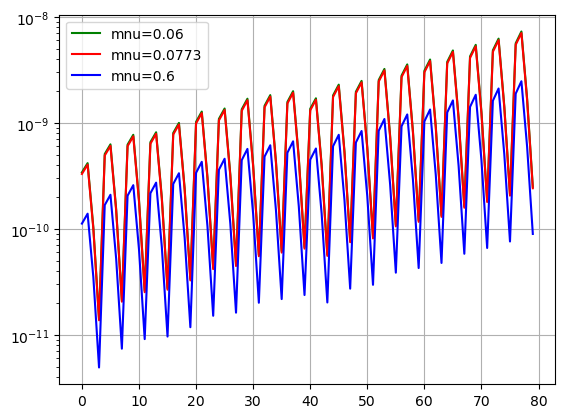

In [21]:
import matplotlib.pyplot as plt

plt.plot(np.arange(80), map3_mnu0, color='g', label='mnu=0.06')
plt.plot(np.arange(80), map3_mnu2, color='r', label='mnu=0.0773')
plt.plot(np.arange(80), map3_mnu1, color='b', label='mnu=0.6')
plt.grid()
plt.legend()
plt.yscale('log')
plt.show()

In [22]:
print(map3_mnu0/map3_mnu2)

[1.03411808 1.03374085 1.033221   1.03236922 1.03404489 1.0336513
 1.03306726 1.03221587 1.03400147 1.03360124 1.0329728  1.03212539
 1.0339876  1.03358604 1.03294348 1.03209785 1.03396267 1.03355528
 1.03288763 1.03204365 1.03390998 1.03349831 1.03276998 1.03193585
 1.03389278 1.03348069 1.03273285 1.03190255 1.03384555 1.03343231
 1.03262614 1.03180801 1.03382256 1.03341021 1.03257729 1.03176563
 1.03379204 1.03338165 1.03251605 1.03171284 1.03387122 1.03345444
 1.03268185 1.03185466 1.03380817 1.03339105 1.03253934 1.03173001
 1.03378714 1.03337107 1.03249378 1.03169103 1.03373113 1.03331809
 1.0323674  1.03158435 1.03370309 1.0332931  1.03230853 1.03153562
 1.03366727 1.03326177 1.03223719 1.03147689 1.03363574 1.0332333
 1.03216001 1.0314145  1.03359759 1.03320126 1.03208369 1.03135337
 1.03354865 1.03316069 1.03199098 1.0312795  1.03347852 1.03310264
 1.03186833 1.0311816 ]


In [8]:
#new analysis with sim dvs
import numpy as np
# Open the FITS file
file_path = '/Users/gchgomes/3pcf_integrator/data/dv/meas_2pt-ave-cosmogrid_weighted.fits'
file2 = '/Users/gchgomes/3pcf_integrator/data/dv/sim_2pt_emu-NLA-cosmoDESY3-14Oct24.fits'

hdul = fits.open(file_path)
hdul_file2 = fits.open(file2)

print(hdul[2].data)
print(hdul_file2[2].data)

for i in range(200):
    hdul[2].data[i][3] = hdul_file2[2].data[i][3]
    hdul[3].data[i][3] = hdul_file2[3].data[i][3]
    
new_file_path = '/Users/gchgomes/3pcf_integrator/data/dv/sim_2pt-desy3c_weighted.fits'
hdul.writeto(new_file_path)

[(1, 1,  0, 7.91835841e-06,   2.5       ,   3.14731353,   2.83602296)
 (1, 1,  1, 6.97802086e-06,   3.14731353,   3.96223298,   3.57034138)
 (1, 1,  2, 6.40204839e-06,   3.96223298,   4.98815579,   4.49479349)
 (1, 1,  3, 5.42942027e-06,   4.98815579,   6.27971608,   5.65860974)
 (1, 1,  4, 3.74596502e-06,   6.27971608,   7.90569415,   7.1237676 )
 (1, 1,  5, 3.23454302e-06,   7.90569415,   9.95267926,   8.96829206)
 (1, 1,  6, 2.50274456e-06,   9.95267926,  12.52968084,  11.29041078)
 (1, 1,  7, 2.13756037e-06,  12.52968084,  15.77393361,  14.21378504)
 (1, 1,  8, 1.66472748e-06,  15.77393361,  19.85820587,  17.89409518)
 (1, 1,  9, 1.38486516e-06,  19.85820587,  25.        ,  22.52733114)
 (1, 1, 10, 1.18002497e-06,  25.        ,  31.47313529,  28.36022963)
 (1, 1, 11, 9.67106818e-07,  31.47313529,  39.62232981,  35.70341377)
 (1, 1, 12, 7.97011115e-07,  39.62232981,  49.88155787,  44.94793488)
 (1, 1, 13, 6.37359147e-07,  49.88155787,  62.79716079,  56.58609743)
 (1, 1, 14, 5.374528

In [12]:
#new analysis with sim dvs
import numpy as np
# Open the FITS file
file_path = '/Users/gchgomes/3pcf_integrator/data/dv/meas_2pt-ave-cosmogrid_weighted_500simcov_17Sep24.fits'
file2 = '/Users/gchgomes/3pcf_integrator/data/dv/sim_2pt_emu-NLA-cosmoDESY3-14Oct24.fits'

hdul = fits.open(file_path)
hdul_file2 = fits.open(file2)

print(hdul.info())
print(hdul_file2.info())

print(hdul[2].data)
print(hdul_file2[2].data)

for i in range(200):
    hdul[2].data[i][3] = hdul_file2[2].data[i][3]
    hdul[3].data[i][3] = hdul_file2[3].data[i][3]
    
new_file_path = '/Users/gchgomes/3pcf_integrator/data/dv/sim_2pt-desy3c_weighted_500simcov.fits'
hdul.writeto(new_file_path)

Filename: /Users/gchgomes/3pcf_integrator/data/dv/meas_2pt-ave-cosmogrid_weighted_500simcov_17Sep24.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU       4   ()      
  1  COVMAT        1 ImageHDU        17   (400, 400)   float64   
  2  xip           1 BinTableHDU     35   200R x 7C   [K, K, K, D, D, D, D]   
  3  xim           1 BinTableHDU     35   200R x 7C   [K, K, K, D, D, D, D]   
  4  nz_source     1 BinTableHDU     24   301R x 7C   [D, D, D, D, D, D, D]   
None
Filename: /Users/gchgomes/3pcf_integrator/data/dv/sim_2pt_emu-NLA-cosmoDESY3-14Oct24.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU       4   ()      
  1  COVMAT        1 ImageHDU        17   (900, 900)   float64   
  2  xip           1 BinTableHDU     35   200R x 7C   [K, K, K, D, D, D, D]   
  3  xim           1 BinTableHDU     35   200R x 7C   [K, K, K, D, D, D, D]   
  4  nz_source     1 BinTableHDU     24   301R 

In [16]:
#new analysis with sim dvs
import numpy as np
# Open the FITS file
file_path = '/Users/gchgomes/3pcf_integrator/data/dv/meas_map3-ave-cosmogrid_weighted.fits'
file2 = '/Users/gchgomes/3pcf_integrator/data/dv/sim_map3_emu-NLA-cosmoDESY3-14Oct24.fits'

hdul = fits.open(file_path)
hdul_file2 = fits.open(file2)

print(hdul.info())
print(hdul_file2.info())

print(hdul[1].data)
print(hdul_file2[1].data)

for i in range(80):
    hdul[1].data[i][6] = hdul_file2[1].data[i][6]
    
new_file_path = '/Users/gchgomes/3pcf_integrator/data/dv/sim_map3-desy3c_weighted.fits'
hdul.writeto(new_file_path)

Filename: /Users/gchgomes/3pcf_integrator/data/dv/meas_map3-ave-cosmogrid_weighted.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU       4   ()      
  1  map3          1 BinTableHDU     29   80R x 7C   [K, K, K, D, D, D, D]   
  2  COVMAT        1 ImageHDU        12   (80, 80)   float64   
None
Filename: /Users/gchgomes/3pcf_integrator/data/dv/sim_map3-desy3c_weighted.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU       4   ()      
  1  map3          1 BinTableHDU     29   80R x 7C   [K, K, K, D, D, D, D]   
  2  COVMAT        1 ImageHDU        12   (80, 80)   float64   
None
[(1, 1, 1,  7.,  7.,  7., 1.03756988e-09)
 (1, 1, 1, 14., 14., 14., 2.79864309e-10)
 (1, 1, 1, 25., 25., 25., 6.12367933e-11)
 (1, 1, 1, 40., 40., 40., 7.76292214e-12)
 (1, 1, 2,  7.,  7.,  7., 1.28640900e-09)
 (1, 1, 2, 14., 14., 14., 4.21525059e-10)
 (1, 1, 2, 25., 25., 25., 8.53216895e-11)
 (1, 1, 2, 40., 40

In [5]:
#create new cov 24 oct 24
import numpy as np
# Open the FITS file
file_path = '/Users/gchgomes/3pcf_integrator/data/covariance/cov_xip_xim_map3_weighted.fits'
file2 = '/Users/gchgomes/3pcf_integrator/data/covariance/xip_xim_map3_covariance_MORECUT_24Oct24.npy'

hdul = fits.open(file_path)
npfile2 = np.load(file2)
hdul.info()

print(npfile2)
print(hdul[1].data)

#hdul[1].data = npfile2

#new_file_path = '/Users/gchgomes/3pcf_integrator/data/covariance/xip_xim_map3_covariance_MORECUT_24Oct24.fits'
#hdul.writeto(new_file_path)

Filename: /Users/gchgomes/3pcf_integrator/data/covariance/cov_xip_xim_map3_weighted.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU       4   ()      
  1  COVMAT        1 ImageHDU        16   (480, 480)   float64   
[[ 9.33242351e-11 -6.14160811e-13  3.87403438e-12 ... -2.23198844e-16
   3.47976162e-17  1.67887583e-18]
 [-6.14160811e-13  1.27098802e-11  5.98344631e-13 ...  3.88732661e-17
  -1.14813453e-17 -9.06383418e-18]
 [ 3.87403438e-12  5.98344631e-13  1.60288505e-11 ... -1.05243033e-16
  -1.80809139e-17 -5.76786853e-18]
 ...
 [-2.23198844e-16  3.88732661e-17 -1.05243033e-16 ...  4.31495647e-19
   5.85752739e-20  4.04328082e-21]
 [ 3.47976162e-17 -1.14813453e-17 -1.80809139e-17 ...  5.85752739e-20
   3.80019559e-20  4.91908182e-21]
 [ 1.67887583e-18 -9.06383418e-18 -5.76786853e-18 ...  4.04328082e-21
   4.91908182e-21  1.61000438e-21]]
[[ 9.35112576e-11 -6.15391594e-13  3.88179797e-12 ... -5.10835923e-17
  -4.29195023e-17 -2.94614

In [8]:
#create new cov 31 oct 24
import numpy as np
# Open the FITS file
file_path = '/Users/gchgomes/3pcf_integrator/data/covariance/cov_xip_xim_map3_weighted.fits'
file2 = '/Users/gchgomes/3pcf_integrator/data/covariance/xip_xim_map3_covariance_5ARCMINCUT_31Oct24.npy'

hdul = fits.open(file_path)
npfile2 = np.load(file2)
hdul.info()

print(npfile2)
print(hdul[1].data)

hdul[1].data = npfile2

new_file_path = '/Users/gchgomes/3pcf_integrator/data/covariance/xip_xim_map3_covariance_5ARCMINCUT_31Oct24.fits'
hdul.writeto(new_file_path)

Filename: /Users/gchgomes/3pcf_integrator/data/covariance/cov_xip_xim_map3_weighted.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU       4   ()      
  1  COVMAT        1 ImageHDU        16   (480, 480)   float64   
[[ 9.33242351e-11 -6.14160811e-13  3.87403438e-12 ... -6.74710942e-16
   4.29543531e-18 -1.28772248e-18]
 [-6.14160811e-13  1.27098802e-11  5.98344631e-13 ...  2.40921975e-16
  -3.62275827e-18 -7.63165083e-18]
 [ 3.87403438e-12  5.98344631e-13  1.60288505e-11 ... -1.21042453e-16
  -1.96639867e-17 -5.20719102e-18]
 ...
 [-6.74710942e-16  2.40921975e-16 -1.21042453e-16 ...  3.14929108e-18
   2.31345927e-19  1.76475504e-20]
 [ 4.29543531e-18 -3.62275827e-18 -1.96639867e-17 ...  2.31345927e-19
   4.97810733e-20  5.76326436e-21]
 [-1.28772248e-18 -7.63165083e-18 -5.20719102e-18 ...  1.76475504e-20
   5.76326436e-21  1.70600737e-21]]
[[ 9.35112576e-11 -6.15391594e-13  3.88179797e-12 ... -5.10835923e-17
  -4.29195023e-17 -2.94614

In [9]:
#create new cov 31 oct 24 6ARCMINCUT
import numpy as np
# Open the FITS file
file_path = '/Users/gchgomes/3pcf_integrator/data/covariance/cov_xip_xim_map3_weighted.fits'
file2 = '/Users/gchgomes/3pcf_integrator/data/covariance/xip_xim_map3_covariance_6ARCMINCUT_31Oct24.npy'

hdul = fits.open(file_path)
npfile2 = np.load(file2)
hdul.info()

print(npfile2)
print(hdul[1].data)

hdul[1].data = npfile2

new_file_path = '/Users/gchgomes/3pcf_integrator/data/covariance/xip_xim_map3_covariance_6ARCMINCUT_31Oct24.fits'
hdul.writeto(new_file_path)

Filename: /Users/gchgomes/3pcf_integrator/data/covariance/cov_xip_xim_map3_weighted.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU       4   ()      
  1  COVMAT        1 ImageHDU        16   (480, 480)   float64   
[[ 9.33242351e-11 -6.14160811e-13  3.87403438e-12 ... -6.67075126e-16
   8.91152608e-18 -2.08606441e-18]
 [-6.14160811e-13  1.27098802e-11  5.98344631e-13 ...  2.38035277e-16
  -6.20959357e-18 -8.24437124e-18]
 [ 3.87403438e-12  5.98344631e-13  1.60288505e-11 ... -1.10520358e-16
  -1.88076526e-17 -5.54091464e-18]
 ...
 [-6.67075126e-16  2.38035277e-16 -1.10520358e-16 ...  3.11988189e-18
   2.32118455e-19  1.78461796e-20]
 [ 8.91152608e-18 -6.20959357e-18 -1.88076526e-17 ...  2.32118455e-19
   4.98453342e-20  5.78063432e-21]
 [-2.08606441e-18 -8.24437124e-18 -5.54091464e-18 ...  1.78461796e-20
   5.78063432e-21  1.70076615e-21]]
[[ 9.35112576e-11 -6.15391594e-13  3.88179797e-12 ... -5.10835923e-17
  -4.29195023e-17 -2.94614

In [10]:
#create new cov 31 oct 24 8ARCMINCUT
import numpy as np
# Open the FITS file
file_path = '/Users/gchgomes/3pcf_integrator/data/covariance/cov_xip_xim_map3_weighted.fits'
file2 = '/Users/gchgomes/3pcf_integrator/data/covariance/xip_xim_map3_covariance_8ARCMINCUT_31Oct24.npy'

hdul = fits.open(file_path)
npfile2 = np.load(file2)
hdul.info()

print(npfile2)
print(hdul[1].data)

hdul[1].data = npfile2

new_file_path = '/Users/gchgomes/3pcf_integrator/data/covariance/xip_xim_map3_covariance_8ARCMINCUT_31Oct24.fits'
hdul.writeto(new_file_path)

Filename: /Users/gchgomes/3pcf_integrator/data/covariance/cov_xip_xim_map3_weighted.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU       4   ()      
  1  COVMAT        1 ImageHDU        16   (480, 480)   float64   
[[ 9.33242351e-11 -6.14160811e-13  3.87403438e-12 ... -1.20748651e-16
   4.99878253e-17  1.23149666e-18]
 [-6.14160811e-13  1.27098802e-11  5.98344631e-13 ... -6.70677767e-20
  -1.63886185e-17 -9.13329469e-18]
 [ 3.87403438e-12  5.98344631e-13  1.60288505e-11 ... -1.24118539e-16
  -1.75293697e-17 -5.35231954e-18]
 ...
 [-1.20748651e-16 -6.70677767e-20 -1.24118539e-16 ...  4.69259547e-19
   6.27642436e-20  4.08980622e-21]
 [ 4.99878253e-17 -1.63886185e-17 -1.75293697e-17 ...  6.27642436e-20
   3.92720971e-20  4.98173214e-21]
 [ 1.23149666e-18 -9.13329469e-18 -5.35231954e-18 ...  4.08980622e-21
   4.98173214e-21  1.63060104e-21]]
[[ 9.35112576e-11 -6.15391594e-13  3.88179797e-12 ... -5.10835923e-17
  -4.29195023e-17 -2.94614

In [6]:
hddu = fits.open(new_file_path)
hddu.info()
print(hddu[1].data)

Filename: /Users/gchgomes/3pcf_integrator/data/covariance/xip_xim_map3_covariance_MORECUT_24Oct24.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU       4   ()      
  1  COVMAT        1 ImageHDU        16   (480, 480)   float64   
[[ 9.33242351e-11 -6.14160811e-13  3.87403438e-12 ... -2.23198844e-16
   3.47976162e-17  1.67887583e-18]
 [-6.14160811e-13  1.27098802e-11  5.98344631e-13 ...  3.88732661e-17
  -1.14813453e-17 -9.06383418e-18]
 [ 3.87403438e-12  5.98344631e-13  1.60288505e-11 ... -1.05243033e-16
  -1.80809139e-17 -5.76786853e-18]
 ...
 [-2.23198844e-16  3.88732661e-17 -1.05243033e-16 ...  4.31495647e-19
   5.85752739e-20  4.04328082e-21]
 [ 3.47976162e-17 -1.14813453e-17 -1.80809139e-17 ...  5.85752739e-20
   3.80019559e-20  4.91908182e-21]
 [ 1.67887583e-18 -9.06383418e-18 -5.76786853e-18 ...  4.04328082e-21
   4.91908182e-21  1.61000438e-21]]


In [5]:
#NOT FINAL: ANALYSIS OCT 28 -- SIM DV AND COSMOGRID_SCALECUT_11ARCMIN_COV

covvv = fits.open('/Users/gchgomes/3pcf_integrator/data/covariance/xip_xim_map3_covariance_MORECUT_24Oct24.fits')
input_map3_file = fits.open('/Users/gchgomes/3pcf_integrator/data/dv/sim_map3-desy3c_weighted.fits')
input_map3_file.info()
covvv.info()

covvvmap3 = covvv[1].data[400:,:][:,400:]
input_map3_file[2].data = covvvmap3

new_file_path = '/Users/gchgomes/3pcf_integrator/data/dv/sim_map3-desy3c_cosmogridcutcov.fits'
input_map3_file.writeto(new_file_path)

Filename: /Users/gchgomes/3pcf_integrator/data/dv/sim_map3-desy3c_weighted.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU       4   ()      
  1  map3          1 BinTableHDU     29   80R x 7C   [K, K, K, D, D, D, D]   
  2  COVMAT        1 ImageHDU        12   (80, 80)   float64   
Filename: /Users/gchgomes/3pcf_integrator/data/covariance/xip_xim_map3_covariance_MORECUT_24Oct24.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU       4   ()      
  1  COVMAT        1 ImageHDU        16   (480, 480)   float64   


In [10]:
covvv = fits.open('/Users/gchgomes/3pcf_integrator/data/covariance/xip_xim_map3_covariance_MORECUT_24Oct24.fits')
input_2pt_file = fits.open('/Users/gchgomes/3pcf_integrator/data/dv/sim_2pt-desy3c_weighted_500simcov.fits')
input_2pt_file.info()
covvv.info()

covvv2pt = covvv[1].data[:400,:][:,:400]
input_2pt_file[1].data = covvv2pt

new_file_path = '/Users/gchgomes/3pcf_integrator/data/dv/sim_2pt-desy3c_cosmogridcutcov_500simcov.fits'
input_2pt_file.writeto(new_file_path)

Filename: /Users/gchgomes/3pcf_integrator/data/dv/sim_2pt-desy3c_weighted_500simcov.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU       4   ()      
  1  COVMAT        1 ImageHDU        17   (400, 400)   float64   
  2  xip           1 BinTableHDU     35   200R x 7C   [K, K, K, D, D, D, D]   
  3  xim           1 BinTableHDU     35   200R x 7C   [K, K, K, D, D, D, D]   
  4  nz_source     1 BinTableHDU     24   301R x 7C   [D, D, D, D, D, D, D]   
Filename: /Users/gchgomes/3pcf_integrator/data/covariance/xip_xim_map3_covariance_MORECUT_24Oct24.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU       4   ()      
  1  COVMAT        1 ImageHDU        16   (480, 480)   float64   


In [5]:
import numpy as np
print(np.logspace(np.log10(0.5), np.log10(80), num=41))
print(np.logspace(np.log10(10.50611122), np.log10(80), num=17))
print(np.logspace(np.log10(6.32455532), np.log10(80), num=21))

[ 0.5         0.56764002  0.64443038  0.73160894  0.83058102  0.94294205
  1.07050328  1.215321    1.37972966  1.56637954  1.77827941  2.01884511
  2.29195454  2.60201022  2.95401025  3.35362886  3.80730788  4.32236061
  4.9070897   5.57092095  6.32455532  7.18014137  8.15147113  9.25420241
 10.50611122 11.92737829 13.54091441 15.37272976 17.45235314 19.81330805
 22.49365301 25.53659512 28.99118655 32.91311521 37.36560252 42.42042245
 48.15905858 54.67401761 62.0703205  70.46719549 80.        ]
[10.50611122 11.92737829 13.54091441 15.37272976 17.45235315 19.81330805
 22.49365301 25.53659513 28.99118655 32.91311522 37.36560252 42.42042245
 48.15905859 54.67401761 62.0703205  70.46719549 80.        ]
[ 6.32455532  7.18014137  8.15147113  9.25420241 10.50611122 11.92737829
 13.54091441 15.37272976 17.45235314 19.81330805 22.49365301 25.53659512
 28.99118655 32.91311521 37.36560252 42.42042245 48.15905858 54.67401761
 62.0703205  70.46719549 80.        ]


In [20]:
#create file with tentative map3v binning:
my_file = fits.open("../data/dv/sim_map3-NLA.fits")
my_file.info()
my_file[1].data

newfilename = "../data/dv/base-tentativemap3v-file.fits"

for i in range(20):
    my_file[1].data[4*i][3] = 9
    my_file[1].data[4*i][4] = 9
    my_file[1].data[4*i][5] = 9
    my_file[1].data[4*i+1][3] = 17
    my_file[1].data[4*i+1][4] = 17
    my_file[1].data[4*i+1][5] = 17
    my_file[1].data[4*i+2][3] = 28
    my_file[1].data[4*i+2][4] = 28
    my_file[1].data[4*i+2][5] = 28
    my_file[1].data[4*i+3][3] = 43
    my_file[1].data[4*i+3][4] = 43
    my_file[1].data[4*i+3][5] = 43
    
my_file.writeto(newfilename)

Filename: ../data/dv/sim_map3-NLA.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU       4   ()      
  1  map3          1 BinTableHDU     29   80R x 7C   [K, K, K, D, D, D, D]   
  2  COVMAT        1 ImageHDU        12   (80, 80)   float64   


In [22]:
#create file with tentative map3v binning:
my_file = fits.open("../data/dv/sim_map3-NLA.fits")
my_file.info()
my_file[1].data

newfilename = "../data/dv/base-tentativemap3v2-file.fits"

for i in range(20):
    my_file[1].data[4*i][3] = 8
    my_file[1].data[4*i][4] = 8
    my_file[1].data[4*i][5] = 8
    my_file[1].data[4*i+1][3] = 16
    my_file[1].data[4*i+1][4] = 16
    my_file[1].data[4*i+1][5] = 16
    my_file[1].data[4*i+2][3] = 28
    my_file[1].data[4*i+2][4] = 28
    my_file[1].data[4*i+2][5] = 28
    my_file[1].data[4*i+3][3] = 45
    my_file[1].data[4*i+3][4] = 45
    my_file[1].data[4*i+3][5] = 45
    
my_file.writeto(newfilename)

Filename: ../data/dv/sim_map3-NLA.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU       4   ()      
  1  map3          1 BinTableHDU     29   80R x 7C   [K, K, K, D, D, D, D]   
  2  COVMAT        1 ImageHDU        12   (80, 80)   float64   


In [23]:
#create file with tentative map3v binning:
my_file = fits.open("../data/dv/sim_map3-NLA.fits")
my_file.info()
my_file[1].data

newfilename = "../data/dv/base-tentativemap3v3-file.fits"

for i in range(20):
    my_file[1].data[4*i][3] = 6
    my_file[1].data[4*i][4] = 6
    my_file[1].data[4*i][5] = 6
    my_file[1].data[4*i+1][3] = 12
    my_file[1].data[4*i+1][4] = 12
    my_file[1].data[4*i+1][5] = 12
    my_file[1].data[4*i+2][3] = 24
    my_file[1].data[4*i+2][4] = 24
    my_file[1].data[4*i+2][5] = 24
    my_file[1].data[4*i+3][3] = 40
    my_file[1].data[4*i+3][4] = 40
    my_file[1].data[4*i+3][5] = 40
    
my_file.writeto(newfilename)

Filename: ../data/dv/sim_map3-NLA.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU       4   ()      
  1  map3          1 BinTableHDU     29   80R x 7C   [K, K, K, D, D, D, D]   
  2  COVMAT        1 ImageHDU        12   (80, 80)   float64   


In [21]:
my_file = fits.open("../data/dv/base-tentativemap3v-file.fits")
my_file.info()
my_file[1].data

Filename: ../data/dv/base-tentativemap3v-file.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU       4   ()      
  1  map3          1 BinTableHDU     29   80R x 7C   [K, K, K, D, D, D, D]   
  2  COVMAT        1 ImageHDU        12   (80, 80)   float64   


FITS_rec([(1, 1, 1,  9.,  9.,  9., 2.61622411e-10),
          (1, 1, 1, 17., 17., 17., 1.13274848e-10),
          (1, 1, 1, 28., 28., 28., 2.59703414e-11),
          (1, 1, 1, 43., 43., 43., 3.38098519e-12),
          (1, 1, 2,  9.,  9.,  9., 4.79337363e-10),
          (1, 1, 2, 17., 17., 17., 1.90407428e-10),
          (1, 1, 2, 28., 28., 28., 4.14345574e-11),
          (1, 1, 2, 43., 43., 43., 5.21501994e-12),
          (1, 1, 3,  9.,  9.,  9., 5.55584821e-10),
          (1, 1, 3, 17., 17., 17., 2.16331415e-10),
          (1, 1, 3, 28., 28., 28., 4.65513381e-11),
          (1, 1, 3, 43., 43., 43., 5.82000441e-12),
          (1, 1, 4,  9.,  9.,  9., 5.71590937e-10),
          (1, 1, 4, 17., 17., 17., 2.21361995e-10),
          (1, 1, 4, 28., 28., 28., 4.74911563e-11),
          (1, 1, 4, 43., 43., 43., 5.92706593e-12),
          (1, 2, 2,  9.,  9.,  9., 9.90066650e-10),
          (1, 2, 2, 17., 17., 17., 3.55381190e-10),
          (1, 2, 2, 28., 28., 28., 7.32269195e-11),
          (1

In [28]:
#Files with sim dv at cosmogrid cov. Both dv and covariance with a scale cut at 8 arcmin: 
#This is the final version dated 4 Nov 2024

#new analysis with sim dvs
import numpy as np
# Open the FITS file
file_path = '/Users/gchgomes/3pcf_integrator/data/dv/meas_2pt-ave-cosmogrid_weighted_500simcov_17Sep24.fits'
file2 = '/Users/gchgomes/3pcf_integrator/data/dv/sim_2pt-NLA-cosmoCosmogrid-04Nov24.fits'

hdul = fits.open(file_path)
hdul_file2 = fits.open(file2)

print(hdul.info())
print(hdul_file2.info())

print(hdul[2].data)
print(hdul_file2[2].data)

for i in range(200):
    hdul[2].data[i][3] = hdul_file2[2].data[i][3]
    hdul[3].data[i][3] = hdul_file2[3].data[i][3]
    
new_file_path = '/Users/gchgomes/3pcf_integrator/data/dv/sim_2pt-NLA-cosmoCosmogrid-04Nov24_500simcov.fits'
hdul.writeto(new_file_path)

Filename: /Users/gchgomes/3pcf_integrator/data/dv/sim_2pt-NLA-cosmoCosmogrid-04Nov24_500simcov.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU       4   ()      
  1  COVMAT        1 ImageHDU        17   (400, 400)   float64   
  2  xip           1 BinTableHDU     35   200R x 7C   [K, K, K, D, D, D, D]   
  3  xim           1 BinTableHDU     35   200R x 7C   [K, K, K, D, D, D, D]   
  4  nz_source     1 BinTableHDU     24   301R x 7C   [D, D, D, D, D, D, D]   
None
Filename: /Users/gchgomes/3pcf_integrator/data/dv/sim_2pt-NLA-cosmoCosmogrid-04Nov24.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU       4   ()      
  1  COVMAT        1 ImageHDU        17   (900, 900)   float64   
  2  xip           1 BinTableHDU     35   200R x 7C   [K, K, K, D, D, D, D]   
  3  xim           1 BinTableHDU     35   200R x 7C   [K, K, K, D, D, D, D]   
  4  nz_source     1 BinTableHDU     24   301R x 7C 

In [2]:
#Now for the map3:

from astropy.io import fits
import numpy as np
# Open the FITS file
filepath = '/Users/gchgomes/3pcf_integrator/data/dv/sim_map3_emu-NLA-cosmoCosmogrid-2Nov24-8arcmincut.fits'
covpath = '/Users/gchgomes/3pcf_integrator/data/covariance/xip_xim_map3_covariance_8ARCMINCUT_31Oct24.fits'

hdul = fits.open(filepath)
hdul_file2 = fits.open(covpath)

print(hdul.info())
print(hdul_file2.info())

print(hdul[2].data)
print(hdul_file2[1].data[400][400])

for i in range(80):
    x = hdul[1].data[i][6]
    hdul[1].data[i][6] = -1*x
    for j in range(80):
        hdul[2].data[i][j] = hdul_file2[1].data[400+i][400+j]
    
new_file_path = '/Users/gchgomes/3pcf_integrator/data/dv/sim_map3-cosmoCosmogrid-6Nov24-8arcmincut-WITH_COV.fits'
hdul.writeto(new_file_path)

Filename: /Users/gchgomes/3pcf_integrator/data/dv/sim_map3_emu-NLA-cosmoCosmogrid-2Nov24-8arcmincut.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU       4   ()      
  1  map3          1 BinTableHDU     29   80R x 7C   [K, K, K, D, D, D, D]   
  2  COVMAT        1 ImageHDU        12   (80, 80)   float64   
None
Filename: /Users/gchgomes/3pcf_integrator/data/covariance/xip_xim_map3_covariance_8ARCMINCUT_31Oct24.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU       4   ()      
  1  COVMAT        1 ImageHDU        16   (480, 480)   float64   
None
[[ 3.23214678e-16  6.28688783e-18  1.34647838e-19 ... -5.06214798e-18
  -9.46868551e-20 -1.17533530e-19]
 [ 6.28688783e-18  4.04340966e-19  2.49915530e-20 ... -4.21779124e-20
  -2.13548327e-21 -5.17987476e-21]
 [ 1.34647838e-19  2.49915530e-20  8.68927283e-21 ... -6.27419077e-21
  -2.53430838e-21 -6.89025152e-22]
 ...
 [-5.06214798e-18 -4.2177

In [10]:
#TEST FOR SHIVAM! COVARIANCE WITH 400 SIMS
import numpy as np
from astropy.io import fits
# Open the FITS file
file_path = '/Users/gchgomes/3pcf_integrator/data/covariance/cov_xip_xim_map3_weighted.fits'
file2 = '/Users/gchgomes/3pcf_integrator/data/covariance/xip_xim_map3_covariance_8ARCMINCUT_400SIMCOV_9Nov.npy'

hdul = fits.open(file_path)
npfile2 = np.load(file2)
hdul.info()

#print(npfile2)
#print(hdul[1].data)

print(hdul[1].header)

hdul[1].data = npfile2
hdul[1].header['NSIM'] = 400

print(hdul[1].header)

new_file_path = '/Users/gchgomes/3pcf_integrator/data/covariance/xip_xim_map3_covariance_8ARCMINCUT_400SIMCOV_9Nov.fits'
hdul.writeto(new_file_path)

Filename: /Users/gchgomes/3pcf_integrator/data/covariance/cov_xip_xim_map3_weighted.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU       4   ()      
  1  COVMAT        1 ImageHDU        16   (480, 480)   float64   
XTENSION= 'IMAGE   '           / Image extension                                BITPIX  =                  -64 / array data type                                NAXIS   =                    2 / number of array dimensions                     NAXIS1  =                  480                                                  NAXIS2  =                  480                                                  PCOUNT  =                    0 / number of parameters                           GCOUNT  =                    1 / number of groups                               EXTNAME = 'COVMAT  '                                                            NSIM    =                  500                                                  3PT_DATA=   

In [11]:
#Files with sim dv at cosmogrid cov. Both dv and covariance with a scale cut at 8 arcmin: 
#This is the 400simcov version for shivam

#new analysis with sim dvs
import numpy as np
# Open the FITS file
file_path = '/Users/gchgomes/3pcf_integrator/data/dv/sim_2pt-NLA-cosmoCosmogrid-04Nov24_500simcov.fits'
file2 = '/Users/gchgomes/3pcf_integrator/data/covariance/xip_xim_map3_covariance_8ARCMINCUT_400SIMCOV_9Nov.npy'

hdul = fits.open(file_path)
covvv = np.load(file2)

print(hdul.info())

for i in range(400):
    for j in range(400):
        hdul[1].data[i][j] = covvv[i][j]
        
print(hdul[1].header)
    
new_file_path = '/Users/gchgomes/3pcf_integrator/data/dv/sim_2pt-NLA-cosmoCosmogrid-400simcov_9Nov.fits'
hdul.writeto(new_file_path)

Filename: /Users/gchgomes/3pcf_integrator/data/dv/sim_2pt-NLA-cosmoCosmogrid-04Nov24_500simcov.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU       4   ()      
  1  COVMAT        1 ImageHDU        17   (400, 400)   float64   
  2  xip           1 BinTableHDU     35   200R x 7C   [K, K, K, D, D, D, D]   
  3  xim           1 BinTableHDU     35   200R x 7C   [K, K, K, D, D, D, D]   
  4  nz_source     1 BinTableHDU     24   301R x 7C   [D, D, D, D, D, D, D]   
None
XTENSION= 'IMAGE   '           / Image extension                                BITPIX  =                  -64 / array data type                                NAXIS   =                    2 / number of array dimensions                     NAXIS1  =                  400                                                  NAXIS2  =                  400                                                  PCOUNT  =                    0 / number of parameters                          

In [12]:
#Now for the 400simcov map3:

from astropy.io import fits
import numpy as np
# Open the FITS file
filepath = '/Users/gchgomes/3pcf_integrator/data/dv/sim_map3-cosmoCosmogrid-6Nov24-8arcmincut-WITH_COV.fits'
covpath = '/Users/gchgomes/3pcf_integrator/data/covariance/xip_xim_map3_covariance_8ARCMINCUT_400SIMCOV_9Nov.fits'

hdul = fits.open(filepath)
hdul_file2 = fits.open(covpath)

print(hdul.info())
print(hdul_file2.info())

print(hdul[2].data)
print(hdul_file2[1].data[400][400])

for i in range(80):
    for j in range(80):
        hdul[2].data[i][j] = hdul_file2[1].data[400+i][400+j]
        
print(hdul[2].header)
    
#new_file_path = '/Users/gchgomes/3pcf_integrator/data/dv/sim_map3-cosmoCosmogrid-8arcmincut-400SIMCOV_9Nov.fits'
#hdul.writeto(new_file_path)

Filename: /Users/gchgomes/3pcf_integrator/data/dv/sim_map3-cosmoCosmogrid-6Nov24-8arcmincut-WITH_COV.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU       4   ()      
  1  map3          1 BinTableHDU     29   80R x 7C   [K, K, K, D, D, D, D]   
  2  COVMAT        1 ImageHDU        12   (80, 80)   float64   
None
Filename: /Users/gchgomes/3pcf_integrator/data/covariance/xip_xim_map3_covariance_8ARCMINCUT_400SIMCOV_9Nov.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU       4   ()      
  1  COVMAT        1 ImageHDU        16   (480, 480)   float64   
None
[[ 7.47941309e-19  4.52497440e-20  3.34850235e-22 ... -2.47838669e-20
  -2.37777011e-21 -8.05659955e-22]
 [ 4.52497440e-20  7.03278179e-20  6.86184226e-21 ...  1.46671785e-20
   4.85465965e-21  2.82362890e-22]
 [ 3.34850235e-22  6.86184226e-21  3.94934811e-21 ...  4.48714545e-21
   3.66148283e-22  9.95916419e-23]
 ...
 [-2.47838669e-20

In [11]:
from astropy.io import fits
import numpy as np
# Open the FITS file
file_baryon_map3 = '/Users/gchgomes/3pcf_integrator/data/dv/sim_map3_emu-NLA-cosmoCosmogrid-8arcmincut-december-OWLS-baryon.fits'
file_baryon_2pt = '/Users/gchgomes/3pcf_integrator/data/dv/sim_2pt_emu-NLA-cosmoCosmogrid-8arcmincut-december-OWLS-baryon.fits'

file_dm_map3 = '/Users/gchgomes/3pcf_integrator/data/dv/sim_map3_emu-NLA-cosmoCosmogrid-02DECEMBER_WITH_COV.fits'
file_dm_2pt = '/Users/gchgomes/3pcf_integrator/data/dv/sim_2pt-NLA-cosmoCosmogrid-04Nov24_500simcov.fits'

new_baryon_file = '/Users/gchgomes/3pcf_integrator/data/dv/sim_map3_emu-NLA-cosmoCosmogrid-13DECEMBER_OWLS_BARYON.fits'
new_baryon_2pt = '/Users/gchgomes/3pcf_integrator/data/dv/sim_2pt-NLA-cosmoCosmogrid-13Dec24-OWLS_BARYON_500simcov.fits'

baryon_map3 = fits.open(file_baryon_map3)
baryon_2pt = fits.open(file_baryon_2pt)
dm_map3 = fits.open(file_dm_map3)
dm_2pt = fits.open(file_dm_2pt)

baryon_2pt.info()
print(baryon_map3[1].data)
#print(dm_2pt[3].data)

for i in range(80):
    dm_map3[1].data[i][6] = baryon_map3[1].data[i][6]
    
for i in range(200):
    dm_2pt[2].data[i][3] = baryon_2pt[2].data[i][3]
    dm_2pt[3].data[i][3] = baryon_2pt[3].data[i][3]
    
#dm_map3.writeto(new_baryon_file)
#dm_2pt.writeto(new_baryon_2pt)

Filename: /Users/gchgomes/3pcf_integrator/data/dv/sim_2pt_emu-NLA-cosmoCosmogrid-8arcmincut-december-OWLS-baryon.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU       4   ()      
  1  COVMAT        1 ImageHDU        17   (900, 900)   float64   
  2  xip           1 BinTableHDU     35   200R x 7C   [K, K, K, D, D, D, D]   
  3  xim           1 BinTableHDU     35   200R x 7C   [K, K, K, D, D, D, D]   
  4  nz_source     1 BinTableHDU     24   301R x 7C   [D, D, D, D, D, D, D]   
[(1, 1, 1,  7.,  7.,  7., 4.52669863e-10)
 (1, 1, 1, 14., 14., 14., 2.23652939e-10)
 (1, 1, 1, 25., 25., 25., 5.22604010e-11)
 (1, 1, 1, 40., 40., 40., 7.05648682e-12)
 (1, 1, 2,  7.,  7.,  7., 6.53368466e-10)
 (1, 1, 2, 14., 14., 14., 3.06159390e-10)
 (1, 1, 2, 25., 25., 25., 6.99384111e-11)
 (1, 1, 2, 40., 40., 40., 9.38242448e-12)
 (1, 1, 3,  7.,  7.,  7., 7.82565007e-10)
 (1, 1, 3, 14., 14., 14., 3.57200866e-10)
 (1, 1, 3, 25., 25., 25., 8.08509368e-11)
 (1,

In [12]:
from astropy.io import fits
import numpy as np
# Open the FITS file

file_baryon_2pt = '/Users/gchgomes/3pcf_integrator/data/dv/sim_2pt_emu-NLA-cosmoCosmogrid-8arcmincut-december-OWLS-baryon.fits'
file_dm_2pt = '/Users/gchgomes/3pcf_integrator/data/dv/sim_2pt-NLA-cosmoCosmogrid-04Nov24.fits'

new_baryon_2pt_2 = '/Users/gchgomes/3pcf_integrator/data/dv/sim_2pt-NLA-cosmoCosmogrid-13Dec24-baryon.fits'

baryon_2pt = fits.open(file_baryon_2pt)
dm_2pt = fits.open(file_dm_2pt)
    
for i in range(200):
    dm_2pt[2].data[i][3] = baryon_2pt[2].data[i][3]
    dm_2pt[3].data[i][3] = baryon_2pt[3].data[i][3]

dm_2pt.writeto(new_baryon_2pt_2)